In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="darkgrid")
df = pd.read_csv("../data/clean_listings.csv")
print(df["segment"].value_counts())

segment
Budget       355
Luxury        74
Mid-Range     37
Name: count, dtype: int64


In [2]:
df_model = pd.get_dummies(df, columns=["type", "district", "city"], drop_first=True)

target = "segment"
drop_cols = ["title", "location", "price_qar", "segment"]
X = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])
y = df_model["segment"]

mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

print(f"Features: {X.shape[1]} | Samples: {X.shape[0]}")

Features: 77 | Samples: 466


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# stratify=y ensures each segment is proportionally represented in train/test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

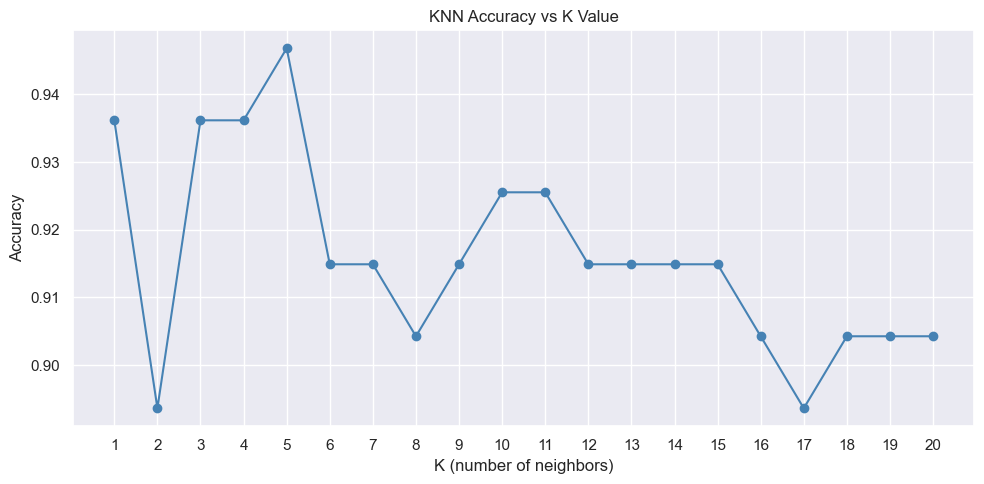

Best K: 5 with accuracy: 0.947


In [4]:
# Try different values of K and see which gives best accuracy
accuracies = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(knn.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 5))
plt.plot(k_range, accuracies, marker="o", color="steelblue")
plt.title("KNN Accuracy vs K Value")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Accuracy")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

best_k = k_range[accuracies.index(max(accuracies))]
print(f"Best K: {best_k} with accuracy: {max(accuracies):.3f}")

In [5]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
preds = knn.predict(X_test_scaled)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

      Budget       0.95      1.00      0.97        72
      Luxury       1.00      0.73      0.85        15
   Mid-Range       0.86      0.86      0.86         7

    accuracy                           0.95        94
   macro avg       0.93      0.86      0.89        94
weighted avg       0.95      0.95      0.94        94



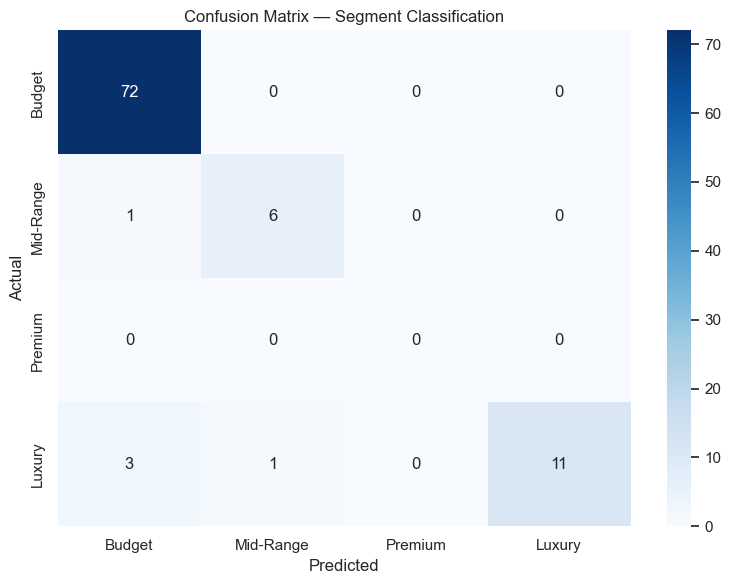

In [6]:
cm = confusion_matrix(y_test, preds, labels=["Budget", "Mid-Range", "Premium", "Luxury"])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Budget", "Mid-Range", "Premium", "Luxury"],
            yticklabels=["Budget", "Mid-Range", "Premium", "Luxury"])
plt.title("Confusion Matrix — Segment Classification")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../data/confusion_matrix.png")
plt.show()